In [2]:
import pandas as pd
import numpy as np

# Number of rows
n = 150

# Generate synthetic data
np.random.seed(42)  # reproducibility
user_id = np.arange(1, n+1)

# Generate values similar to the Iris dataset ranges
sepal_length = np.random.uniform(4.3, 7.9, size=n)   # Sepal length range
sepal_width  = np.random.uniform(2.0, 4.4, size=n)   # Sepal width range
petal_length = np.random.uniform(1.0, 6.9, size=n)   # Petal length range
petal_width  = np.random.uniform(0.1, 2.5, size=n)   # Petal width range

species = np.random.choice(
    ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], 
    size=n
)

# Create DataFrame
df = pd.DataFrame({
    'UserID': user_id,
    'SepalLengthCm': sepal_length.round(2),
    'SepalWidthCm': sepal_width.round(2),
    'PetalLengthCm': petal_length.round(2),
    'PetalWidthCm': petal_width.round(2),
    'Species': species
})


df.to_csv("Iris.csv", index=False)


In [16]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 

In [5]:
df=pd.read_csv("Iris.csv")

In [6]:
print(df)

     UserID  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm  \
0         1           5.65          4.18           1.30          1.97   
1         2           7.72          2.57           4.13          1.44   
2         3           6.94          2.35           4.19          1.12   
3         4           6.46          3.17           4.76          2.28   
4         5           4.86          4.37           5.28          0.37   
..      ...            ...           ...            ...           ...   
145     146           4.43          3.25           6.59          1.24   
146     147           6.49          3.85           6.82          1.70   
147     148           6.11          2.52           5.44          0.51   
148     149           4.49          3.49           3.22          0.56   
149     150           5.30          2.20           1.49          0.20   

             Species  
0        Iris-setosa  
1    Iris-versicolor  
2    Iris-versicolor  
3        Iris-setosa  
4    Iri

In [12]:
x=df.drop('Species',axis=1)
y=df['Species']

In [13]:
from sklearn.model_selection import  train_test_split

In [14]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0)

In [15]:
from sklearn.naive_bayes import  GaussianNB

In [17]:
gaussian=GaussianNB()
gaussian.fit(x_train,y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [18]:
y_train_pred=gaussian.predict(x_train)
y_test_pred=gaussian.predict(x_test)

In [26]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,confusion_matrix

In [21]:
train_accuracy=accuracy_score(y_train,y_train_pred)
test_accuracy=accuracy_score(y_test,y_test_pred)

In [22]:
train_precision=precision_score(y_train,y_train_pred,average='micro')
test_precision=precision_score(y_test,y_test_pred,average='micro')

In [23]:
train_recall=recall_score(y_train,y_train_pred,average='micro')
test_recall=recall_score(y_test,y_test_pred,average='micro')

In [27]:
cm=confusion_matrix(y_test,y_test_pred)

In [28]:
print("Training Accuracy:",train_accuracy)
print("Testing Accuracy:",test_accuracy)
print("Training Precision:",train_precision)
print("Testing Precision:",test_precision)
print("Training Recall:",train_recall)
print("Testing Recall:",test_recall)
print("Confusion Matrix:")
print(cm)


Training Accuracy: 0.5166666666666667
Testing Accuracy: 0.26666666666666666
Training Precision: 0.5166666666666667
Testing Precision: 0.26666666666666666
Training Recall: 0.5166666666666667
Testing Recall: 0.26666666666666666
Confusion Matrix:
[[2 6 2]
 [2 3 5]
 [2 5 3]]


In [29]:
import seaborn as sns


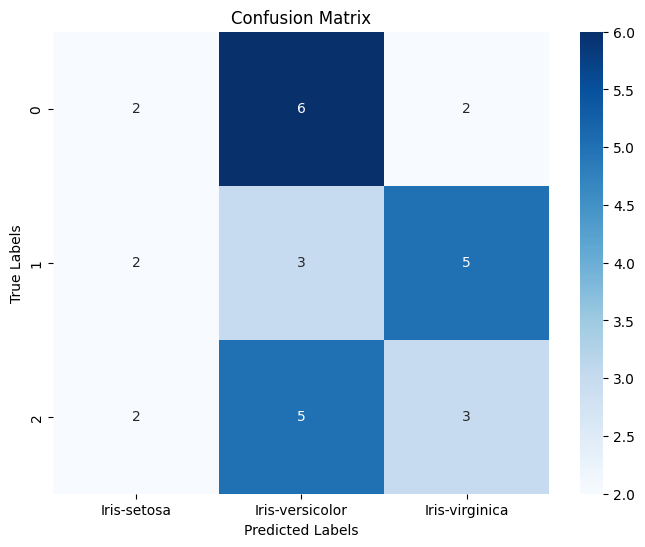

In [31]:
plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=gaussian.classes_)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()